# Implementing Monte Carlo Methods for Estimating Value Functions

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand Monte Carlo methods for value estimation
- Implement first-visit and every-visit Monte Carlo
- Estimate state value functions from sampled episodes
- Compare first-visit and every-visit estimates on the same episodes
- Explain when Monte Carlo fits (episodic tasks) and why TD learning, covered next, updates earlier

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 5, lesson 05 "Performing Sampling and Point Estimation" — a Monte Carlo value estimate is a sample mean of returns, so the bias / variance / consistency vocabulary you built for estimators there is exactly what separates first-visit from every-visit MC.

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 2**:
- Implementing Monte Carlo methods for estimating value functions

---

## Introduction

**Monte Carlo methods** learn value functions from experience (sample episodes). They don't require a model of the environment and use actual returns (sum of rewards) observed from episodes.

## Lesson Brief

This lesson explains how **Monte Carlo methods** estimate values from complete episodes.

Students will see how learning can happen from returns observed after an episode finishes, without needing a model of the environment.

Why this matters: Monte Carlo methods are an important stepping stone between dynamic programming and temporal-difference learning.

They also help students think carefully about what a return actually means.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: how AlphaGo decided whether a Go position was good

In March 2016, in Seoul, AlphaGo beat Lee Sedol — one of the strongest Go players alive — **4 games
to 1**. Underneath that result sits the idea this notebook implements.

Go has roughly 10^170 legal positions; nobody can write down a value for each. So AlphaGo used
**Monte Carlo tree search**: to judge a candidate move it *played the game out* many times from that
point and averaged what happened. Not "estimate the value analytically" — play to the end, record the
result, average, repeat. That is first-visit Monte Carlo evaluation, and it is exactly what the code
below does on FrozenLake: run whole episodes under a fixed policy, wait for each to finish, then
average the returns that followed each tile.

The technique carried the same weakness there as here. AlphaGo's estimate of a position was only as
good as the playouts it had run through it. In game 4 — the one AlphaGo lost — Lee Sedol played move
78; DeepMind's own account afterwards was that AlphaGo's policy network had rated that move as very
unlikely to be played, so its search had barely explored the resulting line, and its evaluations
degraded from there.

**What goes wrong without this.** Without an unbiased way to score a policy you have already got,
"improve the policy" is guesswork. Monte Carlo gives you the honest number: it makes no assumption
about the environment's dynamics and it does not lean on any other estimate. The price is patience —
you must wait for episodes to end — and you must actually *visit* the states you want to know about.
Watch the `tiles visited` column below for what happens when you do not.


## Recommended YouTube Video

To reinforce this lesson, watch **deeplizard - "Reinforcement Learning 5: Monte Carlo methods"**:
[Watch on YouTube](https://www.youtube.com/watch?v=4xfWzLmIccs)

Why this pick:
- focused teaching style.
- Explains episode returns and why Monte Carlo methods wait until trajectories finish.
- Good support for value estimation before TD methods enter the picture.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Return: total discounted reward from now onward.
- Episode-end update: learning after the full episode finishes.
- Sample average: averaging observed returns across episodes.
- Variance: instability in return estimates.
- First-visit vs every-visit: whether a state is updated once or multiple times per episode.

### Quick Check
- Why wait until the episode ends?
- Why are many episodes needed?
- How does this differ from TD methods?
- Why might Monte Carlo be simple but noisy?

### Common Mistakes
- Treating one episode as enough evidence.
- Expecting immediate updates.
- Ignoring high variance.
- Forgetting the difference between first-visit and every-visit updates.


## What this notebook should teach

This notebook is about learning from **complete episodes**.

By the end, you should be able to:

- compute returns from an episode
- explain first-visit vs every-visit Monte Carlo
- estimate state values from sampled episodes


## Monte Carlo in Plain Language

Monte Carlo methods answer a simple question:

`If I watch a full episode finish, what total return did this state really lead to?`

### Why do students often understand Monte Carlo first?

Because it uses a very direct learning story:

- run an episode
- compute the returns
- average what happened

There is no bootstrapping yet.
That makes the logic easier to trust at first.

### Then why not use Monte Carlo for everything?

Because it must wait until the episode ends.
That creates two practical problems:

- learning can be slower
- returns can have high variance across episodes

### First-visit vs every-visit

- **First-visit Monte Carlo** updates a state using only the first time it appears in an episode.
- **Every-visit Monte Carlo** updates a state every time it appears in an episode.

Both use sampled returns, but they organize the evidence slightly differently.

### Bridge to the next notebook

Monte Carlo is important because it teaches students what a return means.
The next step is TD learning, where we stop waiting for the full episode and start learning earlier from partial evidence.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# WHAT: imports plus the environment this notebook estimates values for.
# WHY: Monte Carlo needs EPISODES. Rather than typing episodes by hand, we sample them from
#      Gymnasium's FrozenLake-v1 - a published benchmark whose transition model is also
#      published, so later in the notebook we can check our estimates against the exact answer.

from collections import defaultdict

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
N_STATES = env.observation_space.n
GAMMA = 0.95
TILES = env.unwrapped.desc.astype(str).ravel()      # 'S' start, 'F' frozen, 'H' hole, 'G' goal
TERMINAL = {s for s in range(N_STATES) if TILES[s] in ("H", "G")}
NON_TERMINAL = [s for s in range(N_STATES) if s not in TERMINAL]

# The fixed policy whose value we estimate: 2 = right, 1 = down (Gymnasium's action ids).
# Monte Carlo PREDICTION answers "how good is this policy?", not "what is the best policy?".
POLICY = np.array([2 if (s % 4) < 3 else 1 for s in range(N_STATES)])

print("✅ Libraries imported!")
print("\nImplementing Monte Carlo Methods for Value Estimation")
print("=" * 60)
print("Environment : FrozenLake-v1 (4x4, slippery) — a Gymnasium benchmark")
print("Reward      : +1 for arriving at the goal, 0 everywhere else")
print("Policy      : always try right; in the last column, try down")
for row in range(4):
    print("   " + "  ".join(
        TILES[row * 4 + col] if TILES[row * 4 + col] in ("H", "G")
        else ("→" if POLICY[row * 4 + col] == 2 else "↓")
        for col in range(4)))
print("\nThe ice is slippery: a chosen action succeeds only 1/3 of the time, so the same")
print("policy produces a different episode every run. That is what we average over.")


✅ Libraries imported!

Implementing Monte Carlo Methods for Value Estimation
Environment : FrozenLake-v1 (4x4, slippery) — a Gymnasium benchmark
Reward      : +1 for arriving at the goal, 0 everywhere else
Policy      : always try right; in the last column, try down
   →  →  →  ↓
   →  H  →  H
   →  →  →  H
   H  →  →  G

The ice is slippery: a chosen action succeeds only 1/3 of the time, so the same
policy produces a different episode every run. That is what we average over.


## Part 1: Understanding Monte Carlo Methods


### Step Guide

**What this cell does:** Works the return arithmetic by hand on one tiny three-step episode,
so you can see exactly what `G = r + γ·G` does before any environment is involved.

**How to read it (weak Python OK):** The loop walks the episode **backwards**. That is the trick:
starting from the end, each step's return is "the reward here plus the discounted return of
everything after".

**What to expect in the output:** the episode, the discount factor, and the return computed
from each of its three states.

**If you feel lost:** check the last state by hand — its return is just its own reward, because
nothing follows it.

In [2]:
# WHAT: compute returns by hand on one tiny episode, before touching a real environment.
# WHY: every Monte Carlo method rests on this single line of arithmetic - G = reward + gamma * G,
#      accumulated BACKWARDS from the end of an episode. Get this right and the rest is averaging.

print("=" * 60)
print("Part 1: Understanding Monte Carlo Methods")
print("=" * 60)

# This three-step episode is written out by hand ON PURPOSE: it is a pen-and-paper
# illustration of the arithmetic, small enough to verify in your head. From Part 2 onward,
# every episode is sampled from the real FrozenLake environment instead.
example_episode = [
    ("A", 0),
    ("B", 0),
    ("C", 1),
]
gamma = 0.9

returns = []
G = 0.0
for state, reward in reversed(example_episode):
    # Walking backwards: this state's return is its own reward plus the discounted
    # return of everything that came after it.
    G = reward + gamma * G
    returns.insert(0, (state, G))

print("Example episode:", example_episode)
print("Discount factor:", gamma)
print("Returns from each state:")
for state, g in returns:
    print(f"  State {state}: return = {g:.3f}")
print("\nCheck it by hand: C earns 1 immediately, B earns 0 then 0.9 x 1, A earns 0.9 x 0.9 x 1.")


Part 1: Understanding Monte Carlo Methods
Example episode: [('A', 0), ('B', 0), ('C', 1)]
Discount factor: 0.9
Returns from each state:
  State A: return = 0.810
  State B: return = 0.900
  State C: return = 1.000

Check it by hand: C earns 1 immediately, B earns 0 then 0.9 x 1, A earns 0.9 x 0.9 x 1.


## Part 2: First-Visit Monte Carlo on Sampled Episodes

Now the same arithmetic runs on **episodes we did not write**. We roll the fixed policy on
`FrozenLake-v1` and let the slippery ice generate the trajectories.

**First-visit Monte Carlo** counts a state's return only the *first* time that state appears in
an episode. On slippery ice a policy often visits the same tile several times in one episode,
so this rule genuinely changes what gets averaged — Part 3 measures the difference.

We also compute the **exact** `V^π` by solving the Bellman equation with Gymnasium's published
transition model. That gives us a correct answer to score the estimates against, which a
hand-made environment could never provide.

### Step Guide

**What this cell does:** Run a worked scenario step by step; compare each print to the markdown theory.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [3]:
# WHAT: sample real episodes from FrozenLake, then estimate V(s) with first-visit Monte Carlo.
# WHY: MC is model-free - it only ever sees (state, reward) sequences. The exact V^pi computed
#      alongside it comes from the model and is used ONLY as a scorecard, never by the learner.

print("\n" + "=" * 60)
print("Part 2: First-Visit Monte Carlo Implementation")
print("=" * 60)


def collect_episodes(n_episodes, seed=0):
    """Roll the fixed policy n times; return a list of [(state, reward), ...] trajectories."""
    episodes, lengths, finished = [], [], 0
    for episode_index in range(n_episodes):
        # Seed only the first reset; the environment RNG then rolls on reproducibly.
        state, _ = env.reset(seed=seed) if episode_index == 0 else env.reset()
        trajectory = []
        for _ in range(200):
            next_state, reward, terminated, truncated, _ = env.step(int(POLICY[state]))
            trajectory.append((state, reward))
            state = next_state
            if terminated or truncated:
                finished += int(terminated)
                break
        episodes.append(trajectory)
        lengths.append(len(trajectory))
    return episodes, float(np.mean(lengths)), finished / n_episodes


def exact_state_values(policy, gamma=GAMMA):
    """Solve (I - gamma * P_pi) V = R_pi using Gymnasium's published transition model."""
    model = env.unwrapped.P
    A = np.eye(N_STATES)
    b = np.zeros(N_STATES)
    for s in range(N_STATES):
        if s in TERMINAL:
            continue                                  # terminal tiles keep value 0
        for probability, next_state, reward, _terminated in model[s][int(policy[s])]:
            b[s] += probability * reward
            A[s, next_state] -= gamma * probability
    return np.linalg.solve(A, b)


N_EPISODES = 3000
episodes, mean_length, finish_rate = collect_episodes(N_EPISODES)
V_exact = exact_state_values(POLICY)

# How often does a slippery episode revisit a tile? This is what makes first-visit
# and every-visit two genuinely different rules.
revisits = sum(len(ep) - len({s for s, _ in ep}) for ep in episodes)
print(f"Sampled {N_EPISODES} episodes: mean length {mean_length:.1f} steps, "
      f"{finish_rate * 100:.1f}% reached a terminal tile.")
print(f"Repeat visits inside episodes: {revisits} (slipping sends the agent over tiles twice).")


def first_visit_mc(episodes, gamma=GAMMA):
    """Average the return following the FIRST occurrence of each state in each episode."""
    returns_by_state = defaultdict(list)
    for episode in episodes:
        G = 0.0
        returns = []
        for state, reward in reversed(episode):
            G = reward + gamma * G
            returns.insert(0, (state, G))
        visited = set()
        for state, G in returns:
            if state not in visited:
                returns_by_state[state].append(G)
                visited.add(state)
    return {state: float(np.mean(values)) for state, values in returns_by_state.items()}


fv_values = first_visit_mc(episodes)
print("\n  tile | first-visit MC | exact V^pi | gap")
for s in NON_TERMINAL:
    print(f"  {s:4d} | {fv_values.get(s, float('nan')):14.4f} | "
          f"{V_exact[s]:10.4f} | {fv_values.get(s, float('nan')) - V_exact[s]:+.4f}")



Part 2: First-Visit Monte Carlo Implementation
Sampled 3000 episodes: mean length 5.9 steps, 100.0% reached a terminal tile.
Repeat visits inside episodes: 7454 (slipping sends the agent over tiles twice).

  tile | first-visit MC | exact V^pi | gap
     0 |         0.0245 |     0.0235 | +0.0010
     1 |         0.0242 |     0.0225 | +0.0016
     2 |         0.0502 |     0.0486 | +0.0016
     3 |         0.0172 |     0.0225 | -0.0054
     4 |         0.0270 |     0.0283 | -0.0013
     6 |         0.0828 |     0.0824 | +0.0004
     8 |         0.0670 |     0.0657 | +0.0012
     9 |         0.1582 |     0.1793 | -0.0211
    10 |         0.2172 |     0.2116 | +0.0056
    13 |         0.3536 |     0.3546 | -0.0010
    14 |         0.6071 |     0.5859 | +0.0212


## Part 3: Every-Visit Monte Carlo on the Same Episodes

**Every-visit Monte Carlo** uses the return from *every* occurrence of a state, not just the
first. Both rules see exactly the same episodes here — the only thing that changes is which
returns go into the average.

Sutton & Barto prove both converge to `V^π` as the number of visits grows, so the question is
not "which is correct" but "which is closer after a *finite* number of episodes". The next cell
scores both against the exact answer instead of guessing.

### Step Guide

**What this cell does:** Run a worked scenario step by step; compare each print to the markdown theory.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [4]:
# WHAT: every-visit Monte Carlo on the SAME sampled episodes, scored against the exact V^pi.
# WHY: the only honest way to compare two estimators is to give them identical data and a
#      correct answer to be measured against - which is why the benchmark environment matters.

print("\n" + "=" * 60)
print("Part 3: Every-Visit Monte Carlo Implementation")
print("=" * 60)


def every_visit_mc(episodes, gamma=GAMMA):
    """Average the return following EVERY occurrence of each state."""
    returns_by_state = defaultdict(list)
    for episode in episodes:
        G = 0.0
        returns = []
        for state, reward in reversed(episode):
            G = reward + gamma * G
            returns.insert(0, (state, G))
        for state, G in returns:
            returns_by_state[state].append(G)
    return {state: float(np.mean(values)) for state, values in returns_by_state.items()}


ev_values = every_visit_mc(episodes)


def rms_error(estimates):
    """Root-mean-square gap to the exact V^pi over the tiles the agent can act in."""
    gaps = [estimates.get(s, 0.0) - V_exact[s] for s in NON_TERMINAL]
    return float(np.sqrt(np.mean(np.square(gaps))))


fv_rmse = rms_error(fv_values)
ev_rmse = rms_error(ev_values)
print(f"RMS error vs the exact V^pi after {N_EPISODES} episodes:")
print(f"  first-visit MC : {fv_rmse:.4f}")
print(f"  every-visit MC : {ev_rmse:.4f}")
closer = "first-visit" if fv_rmse < ev_rmse else "every-visit"
print(f"  -> {closer} MC was closer on this run.")

# How does the error fall as episodes accumulate? This is Monte Carlo's real cost.
budgets = [50, 200, 800, 1500, 3000]
convergence = {"first-visit": [], "every-visit": []}
coverage = []
for budget in budgets:
    subset = episodes[:budget]
    fv_subset = first_visit_mc(subset)
    convergence["first-visit"].append(rms_error(fv_subset))
    convergence["every-visit"].append(rms_error(every_visit_mc(subset)))
    # A state MC never visited keeps its initial value of 0 - that counts as error too.
    coverage.append(len([s for s in NON_TERMINAL if s in fv_subset]))

print("\n  episodes | first-visit RMSE | every-visit RMSE | tiles visited")
for i, budget in enumerate(budgets):
    print(f"  {budget:8d} | {convergence['first-visit'][i]:16.4f} | "
          f"{convergence['every-visit'][i]:16.4f} | {coverage[i]:6d} / {len(NON_TERMINAL)}")

print("\nCheckpoint:")
print("If a state appears multiple times in one episode, every-visit MC uses all of them,")
print("while first-visit MC only uses the first occurrence. Both converge to the same")
print("values eventually; the table above shows how slowly 'eventually' arrives.")
print("Read the last column too: with only a few episodes some tiles were never reached at")
print("all, and an unvisited state keeps its starting value of 0. Monte Carlo cannot")
print("estimate what the policy never shows it - that is a coverage problem, not a bug.")



Part 3: Every-Visit Monte Carlo Implementation
RMS error vs the exact V^pi after 3000 episodes:
  first-visit MC : 0.0094
  every-visit MC : 0.0104
  -> first-visit MC was closer on this run.

  episodes | first-visit RMSE | every-visit RMSE | tiles visited
        50 |           0.2260 |           0.2260 |      8 / 11
       200 |           0.1341 |           0.1399 |     11 / 11
       800 |           0.0694 |           0.0622 |     11 / 11
      1500 |           0.0339 |           0.0300 |     11 / 11
      3000 |           0.0094 |           0.0104 |     11 / 11

Checkpoint:
If a state appears multiple times in one episode, every-visit MC uses all of them,
while first-visit MC only uses the first occurrence. Both converge to the same
values eventually; the table above shows how slowly 'eventually' arrives.
Read the last column too: with only a few episodes some tiles were never reached at
all, and an unvisited state keeps its starting value of 0. Monte Carlo cannot
estimate what t

## Monte Carlo in context

Monte Carlo methods are especially natural when:

- the task is episodic
- you can wait until the episode ends
- you want to estimate values directly from sampled returns

They become less convenient when you need online updates before the episode finishes.

### Step Guide

**What this cell does:** Draws two figures — the two MC estimates side by side with the exact
`V^π`, and the error curves from the episode-budget table in Part 3.

**How to read it (weak Python OK):** In the left figure, the grey bar is the correct answer.
The closer the two coloured bars sit to it, the better the estimate.

**What to expect in the output:** one figure with two panels.

**If you feel lost:** look only at the right panel — if both lines fall as episodes increase,
Monte Carlo is converging.

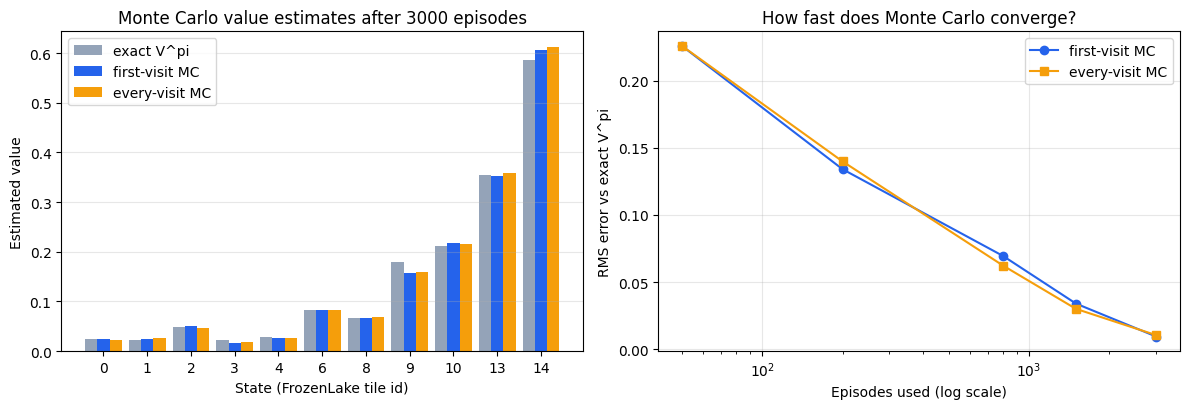

In [5]:
# WHAT: plot both MC estimates against the exact V^pi, and their error against episode count.
# WHY: a bar next to the true value shows accuracy; a falling error curve shows the price MC
#      pays for using only complete episodes.

states = NON_TERMINAL
first_vals = [fv_values.get(s, np.nan) for s in states]
every_vals = [ev_values.get(s, np.nan) for s in states]
exact_vals = [V_exact[s] for s in states]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
x = np.arange(len(states))
axes[0].bar(x - 0.28, exact_vals, width=0.28, label="exact V^pi", color="#94a3b8")
axes[0].bar(x, first_vals, width=0.28, label="first-visit MC", color="#2563eb")
axes[0].bar(x + 0.28, every_vals, width=0.28, label="every-visit MC", color="#f59e0b")
axes[0].set_xticks(x)
axes[0].set_xticklabels(states)
axes[0].set_xlabel("State (FrozenLake tile id)")
axes[0].set_ylabel("Estimated value")
axes[0].set_title(f"Monte Carlo value estimates after {N_EPISODES} episodes")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].plot(budgets, convergence["first-visit"], marker="o", color="#2563eb", label="first-visit MC")
axes[1].plot(budgets, convergence["every-visit"], marker="s", color="#f59e0b", label="every-visit MC")
axes[1].set_xscale("log")
axes[1].set_xlabel("Episodes used (log scale)")
axes[1].set_ylabel("RMS error vs exact V^pi")
axes[1].set_title("How fast does Monte Carlo converge?")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 💬 Discuss

The measured results: after 3000 episodes, first-visit RMSE **0.0094** against every-visit
**0.0104**; at 50 episodes both sat at **0.2260** with only **8 of 11** tiles ever visited; the exact
value of tile 14 is **0.5859** and first-visit MC called it **0.6071**. Argue these out.

1. First-visit won at 3000 episodes (0.0094 vs 0.0104) but every-visit won at 800 and 1500 (0.0622 vs
   0.0694, 0.0300 vs 0.0339). What is the honest sentence to write in a report about which is better —
   and what experiment would you have to run before you were allowed to write something stronger?
2. At 50 episodes, three tiles had never been visited and kept their starting value of 0. A colleague
   reads the table and says "those tiles are worthless". What is wrong with that reading, and how
   would you present the same table so nobody makes that mistake?
3. This estimate is of *one fixed policy* — "always try right, down in the last column". Suppose a
   client wants the value of their **current** dispatch rule before authorising a change. Is that a
   reason to prefer Monte Carlo over the planning methods of Unit 1, or is it a reason to prefer
   planning? Argue both sides before you choose.


## Summary

Monte Carlo methods estimate value from **complete sampled returns**.

### Main takeaways

- First-visit MC uses the first occurrence of a state in each episode.
- Every-visit MC uses all occurrences.
- Both methods are model-free: the learners above only ever saw `(state, reward)` sequences.
- Both usually have higher variance than TD methods.

### What this notebook actually measured

- The episodes came from `FrozenLake-v1`, a Gymnasium benchmark, not from typed-in data.
- The exact `V^π` was solved from Gymnasium's published transition model and used **only as a
  scorecard** — never by the estimators.
- The episode-budget table shows the real cost of Monte Carlo: read your own run's RMS errors
  at 50 versus 3000 episodes. The gap between the two methods is far smaller than the gap
  between a small and a large sample.

### Why this matters

Monte Carlo gives you a clean way to think about learning from complete experience
before moving to TD learning, which updates earlier and more often — and the next notebook
evaluates *the same policy on the same map*, so the two methods can be compared directly.

In [6]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 5, Monte Carlo Methods.
2. Sutton, R. S. (1988). *Learning to Predict by the Methods of Temporal Differences*. Machine Learning, 3. <https://link.springer.com/article/10.1007/BF00115009>
3. Agarwal, R., Schwarzer, M., Castro, P. S. et al. (2021). *Deep Reinforcement Learning at the Edge of the Statistical Precipice*. NeurIPS. <https://arxiv.org/abs/2108.13264>
"""))

## 📚 References

1. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 5, Monte Carlo Methods.
2. Sutton, R. S. (1988). *Learning to Predict by the Methods of Temporal Differences*. Machine Learning, 3. <https://link.springer.com/article/10.1007/BF00115009>
3. Agarwal, R., Schwarzer, M., Castro, P. S. et al. (2021). *Deep Reinforcement Learning at the Edge of the Statistical Precipice*. NeurIPS. <https://arxiv.org/abs/2108.13264>


### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


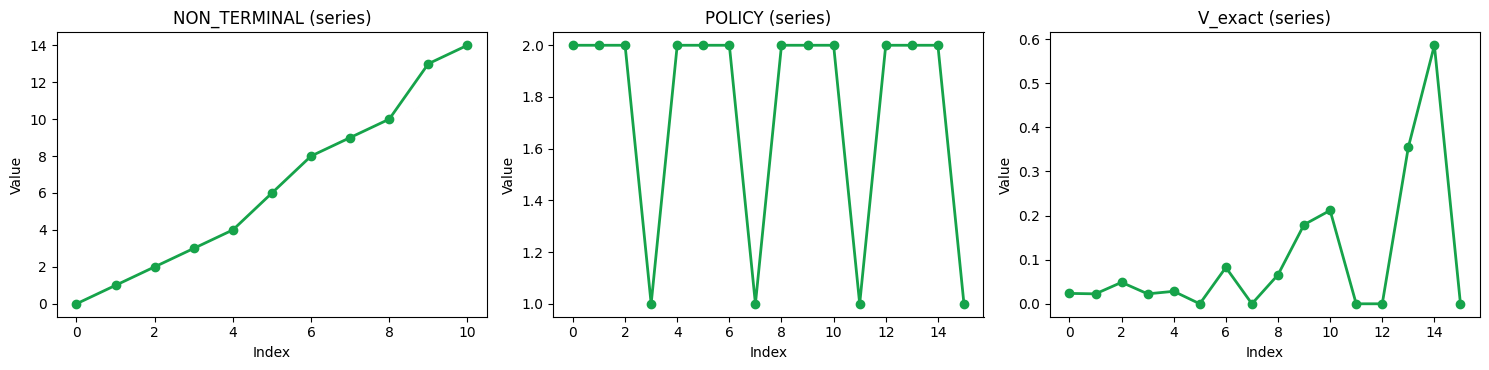

In [7]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## ⚠️ Where this breaks

**The assumption that has to hold:** episodes end, and the policy you are evaluating actually visits
the states you care about.

- **No termination, no estimate.** Monte Carlo needs a completed return before it can update
  anything. A process-control loop, a recommender serving a user for years, a plant that never stops
  — these have no episode boundary. TD learning in the next notebook exists mainly to remove this
  requirement.
- **Coverage is not optional, and it fails quietly.** The `tiles visited` column measured it: 8 of 11
  at 50 episodes. An unvisited state keeps whatever value you initialised it with, and nothing in the
  output distinguishes "worth 0" from "never seen". This is the same failure that Unit 5's
  model-based lesson measures directly: you cannot learn about experience you never collected.
- **Variance is high when rewards are rare.** FrozenLake pays +1 only at the goal, so most episodes
  return 0 and a few return 1. The average converges — slowly. Compare the RMSE column: 0.2260 at 50
  episodes, still 0.0694 at 800. If each episode were a week of factory operation instead of six
  simulated steps, this method would be unusable.
- **Evaluating a policy you did not run is a different, harder problem.** All of the above assumes the
  episodes were generated by the policy being evaluated. Scoring policy B from data collected under
  policy A needs importance sampling, and its variance can be enormous — that is the off-policy
  problem you meet properly in lesson 03.
- **Cheaper alternative:** if you know `P` and `R`, do not sample. One sweep of policy evaluation
  (Unit 1, lesson 02) gives you the exact `V^π` the table above is trying to approximate — which is
  precisely how the "exact V^pi" column was produced.


## Closing Takeaway

**Teaching takeaway:** Monte Carlo methods estimate value from complete episodes, which makes the logic intuitive but can increase variance.

**If students remember one idea:** Monte Carlo waits until the end of the episode, then uses the observed return as the learning signal.

**Quick check before moving on:**
- Can you explain why Monte Carlo needs complete returns before updating?
- Can you describe one advantage and one limitation of waiting until episode end?

**Bridge to the next step:** This leads naturally to temporal-difference learning, which updates earlier and more often.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=25 | term=True | trunc=False


objc[9688]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1143cc138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1148c89c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[9688]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1143cc188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1148c8a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[9688]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1143cbc88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1148c8a68). This

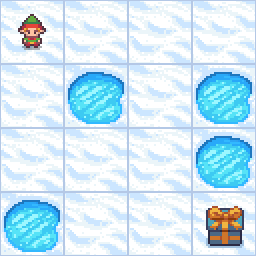

In [8]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
